In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import seaborn as sns
import koreanize_matplotlib
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import gower
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
# 모든 열 다 보기
pd.set_option('display.max_columns', None)

# 너비 제한 없애기 (길게 나올 경우 줄바꿈 없이 한 줄에 표시)
pd.set_option('display.width', None)

In [3]:
data = pd.read_csv(r"C:\Users\jeong\happycircuit\data\real_final_dataset.csv",encoding = "utf-8")

In [4]:
# 사용할 변수 리스트 정의
selected_columns = [
    '시도교육청', '위도', '경도', '이용인원', '1학년 학생수','학교명','시군구',
    '1학년 학급당 학생수', '2학년 학생수', '2학년 학급당 학생수', '3학년 학생수', '3학년 학급당 학생수',
    '4학년 학생수', '4학년 학급당 학생수', '5학년 학생수', '5학년 학급당 학생수', '6학년 학생수',
    '6학년 학급당 학생수', '특수학급 학생수', '특수학급 학급당 학생수', '학생수(계)',
    '학급당 학생수(계)', '교사수', '수업교원 1인당 학생수', '다문화자녀수', '2023_총수입금액(백만원)',
    '교지면적(m)', '학생1인당교지면적', '이용비율'
]

# 원본 데이터에서 선택
data = data[selected_columns].copy()


In [5]:
# 데이터프레임 전체 결측치 확인
data.isnull().sum()

시도교육청               0
위도                  0
경도                  0
이용인원                0
1학년 학생수             0
학교명                 0
시군구                53
1학년 학급당 학생수         0
2학년 학생수             0
2학년 학급당 학생수         0
3학년 학생수             0
3학년 학급당 학생수         0
4학년 학생수             0
4학년 학급당 학생수         0
5학년 학생수             0
5학년 학급당 학생수         0
6학년 학생수             0
6학년 학급당 학생수         0
특수학급 학생수            0
특수학급 학급당 학생수        0
학생수(계)              0
학급당 학생수(계)          0
교사수                 0
수업교원 1인당 학생수        0
다문화자녀수              0
2023_총수입금액(백만원)    53
교지면적(m)             0
학생1인당교지면적           0
이용비율                0
dtype: int64

In [6]:
data = data.dropna()

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 수치형 변수만 추출
numeric_data = data.select_dtypes(include=["float64", "int64"])

# 결측치 제거 (필요 시 활성화)
numeric_data = numeric_data.dropna()

# 표준화
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# VIF 계산
vif_df = pd.DataFrame()
vif_df["variable"] = numeric_data.columns
vif_df["VIF"] = [variance_inflation_factor(scaled_data, i) for i in range(scaled_data.shape[1])]

In [8]:
vif_df

,variable,VIF
0,위도,1.241780
1,경도,1.160332
2,이용인원,2.699370
3,1학년 학생수,17291.888360
4,1학년 학급당 학생수,13.140100
5,2학년 학생수,19154.916571
6,2학년 학급당 학생수,14.196759
7,3학년 학생수,18108.503077
8,3학년 학급당 학생수,14.756893
9,4학년 학생수,17586.170084


돌봄교실 이용 학생의 대부분이 저학년이기 때문에 저학년 비율이 돌봄교실 운영에 영향을 끼칠 것이라고 판단하여 [저학년비율,고학년비율]이라는 변수를 만든다.

In [9]:
# 저학년, 고학년
# 비율로 대체

data['저학년 비율'] = (data['1학년 학생수'] + data['2학년 학생수']+data['3학년 학생수']) / data['학생수(계)']
data['고학년 비율'] = (data['4학년 학생수'] + data['5학년 학생수']+data['6학년 학생수']) / data['학생수(계)']

In [10]:
# 학년별 학생수 컬럼 제거
columns_to_drop = [
    '1학년 학생수', '2학년 학생수', '3학년 학생수',
    '4학년 학생수', '5학년 학생수', '6학년 학생수',
    '학생수(계)','교사수','학급당 학생수(계)'
]

data = data.drop(columns=columns_to_drop)

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 수치형 변수만 추출
numeric_data = data.select_dtypes(include=["float64", "int64"])

# 결측치 제거 (필요 시 활성화)
numeric_data = numeric_data.dropna()

# 표준화
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# VIF 계산
vif_df = pd.DataFrame()
vif_df["variable"] = numeric_data.columns
vif_df["VIF"] = [variance_inflation_factor(scaled_data, i) for i in range(scaled_data.shape[1])]

vif_df


,variable,VIF
0,위도,1.235467
1,경도,1.161157
2,이용인원,1.934979
3,1학년 학급당 학생수,8.957947
4,2학년 학급당 학생수,10.139467
5,3학년 학급당 학생수,10.718942
6,4학년 학급당 학생수,10.692943
7,5학년 학급당 학생수,10.444440
8,6학년 학급당 학생수,9.521190
9,특수학급 학생수,3.327740


VIF 확인 결과, '수업교원 1인당 학생수'에서 높게 나타나지만 이는 인적자원 관리 차원에서 빠질 수 없는 변수라고 판단해 클러스터링을 진행한다.

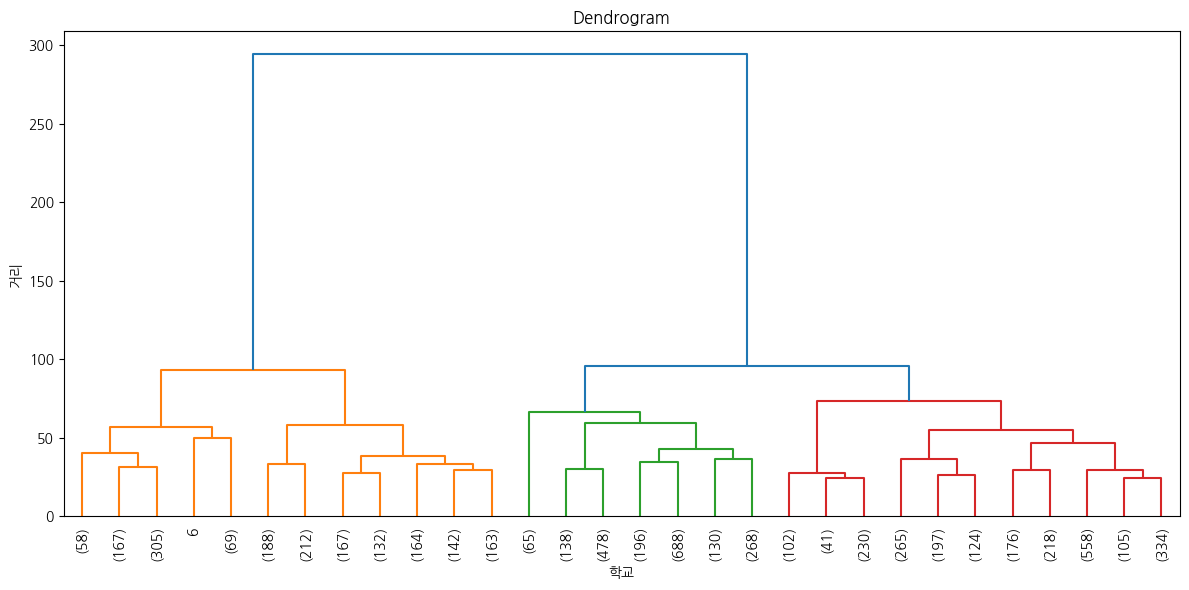

=== 클러스터별 학교 수 ===
cluster
1    1768
2    1963
3    2350
Name: count, dtype: int64

=== 클러스터별 평균 ===
          이용인원  1학년 학급당 학생수  2학년 학급당 학생수  3학년 학급당 학생수  4학년 학급당 학생수  \
cluster                                                              
1        22.76         5.83         6.40         6.64         6.61   
2        71.20        22.63        23.49        23.62        23.69   
3        48.32        19.06        20.40        20.62        20.82   

         5학년 학급당 학생수  6학년 학급당 학생수  특수학급 학생수  특수학급 학급당 학생수  수업교원 1인당 학생수  \
cluster                                                                   
1               7.40         7.66      1.71          1.63          5.60   
2              23.97        23.83      9.17          5.51         18.76   
3              21.16        21.09      4.82          3.54         16.08   

         다문화자녀수  2023_총수입금액(백만원)   교지면적(m)  학생1인당교지면적  이용비율  저학년 비율  고학년 비율  
cluster                                                                      
1         60.78 

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 클러스터링에 사용할 변수만 선택 (식별자 제외)
cluster_columns = [
    '이용인원',
    '1학년 학급당 학생수', '2학년 학급당 학생수', '3학년 학급당 학생수',
    '4학년 학급당 학생수', '5학년 학급당 학생수',
    '6학년 학급당 학생수', '특수학급 학생수', '특수학급 학급당 학생수',
    '수업교원 1인당 학생수', '다문화자녀수', '2023_총수입금액(백만원)',
    '교지면적(m)', '학생1인당교지면적', '이용비율','저학년 비율','고학년 비율'
]

cluster_data = data[cluster_columns].dropna()



# 표준화
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_data)


# 덴드로그램으로 클러스터 수 확인
linked = linkage(scaled, method='ward')

k = 3
labels = fcluster(linked, k, criterion='maxclust')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90,color_threshold=95)
plt.title('Dendrogram')
plt.xlabel('학교')
plt.ylabel('거리')
plt.tight_layout()
plt.show()


cluster_data = cluster_data.copy()
cluster_data['cluster'] = labels

print("=== 클러스터별 학교 수 ===")
print(cluster_data['cluster'].value_counts().sort_index())

print("\n=== 클러스터별 평균 ===")
print(cluster_data.groupby('cluster').mean().round(2))

In [13]:
# 원본 data에 클러스터 레이블 붙이기
data['cluster'] = cluster_data['cluster']

# 확인
print(data[['학교명', '시군구', 'cluster']].head(10))

           학교명   시군구  cluster
0      가거도초등학교   신안군        1
1       가경초등학교   청주시        2
2      가고파초등학교   창원시        3
3       가곡초등학교  남양주시        2
4       가곡초등학교   단양군        1
5  가곡초등학교대곡분교장   단양군        1
6  가곡초등학교보발분교장   단양군        1
7       가남초등학교  부산진구        1
8       가남초등학교   양산시        2
9       가남초등학교   청양군        1


In [14]:
print(f"클러스터 배정된 학교: {data['cluster'].notna().sum()}")
print(f"클러스터 미배정 학교: {data['cluster'].isna().sum()}")

클러스터 배정된 학교: 6081
클러스터 미배정 학교: 0


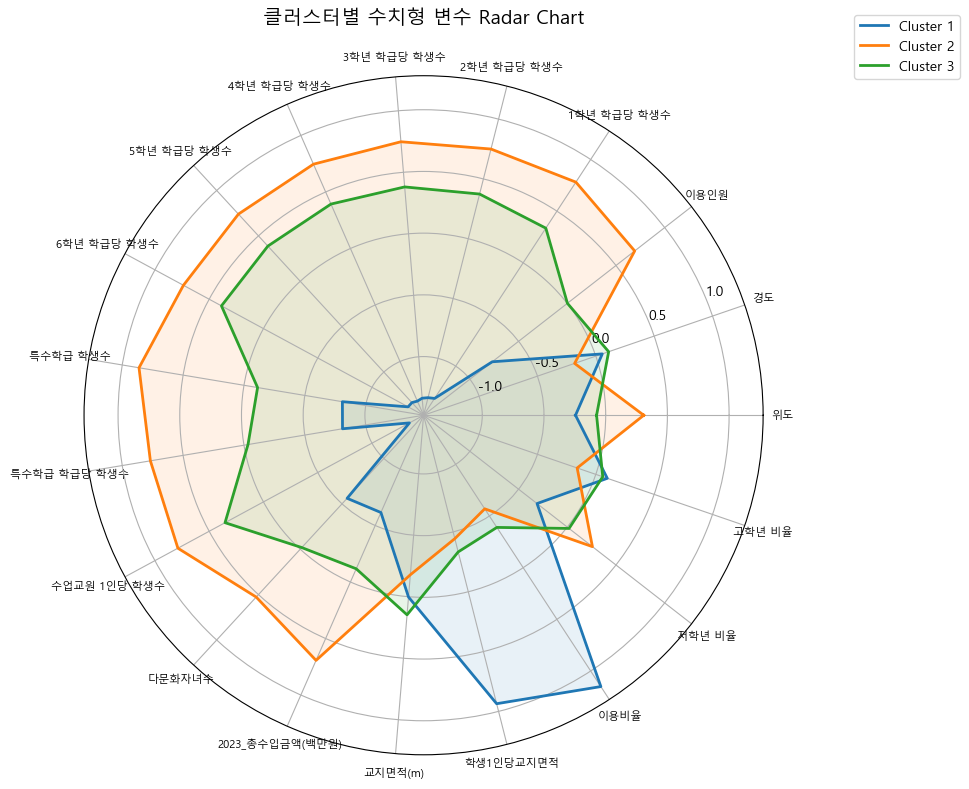

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

# 1. 수치형 변수만 추출
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = [col for col in numeric_cols if col != "cluster"]

# 2. 수치형 변수만 따로 저장
data_numeric = data[numeric_cols]

# 3. 표준화
data_normalized = (data_numeric - data_numeric.mean()) / data_numeric.std()

# 4. cluster 붙이기
data_normalized["cluster"] = data["cluster"].values

# 5. 군집별 평균 계산
cluster_means_norm = data_normalized.groupby("cluster").mean()

# 6. Radar Chart
labels = cluster_means_norm.columns.tolist()
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, (idx, row) in enumerate(cluster_means_norm.iterrows()):
    values = row[labels].tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Cluster {idx}', linewidth=2, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=8)
ax.set_title("클러스터별 수치형 변수 Radar Chart", size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()
